# Hodgkin-Huxley Model
*Owen Page (2025), based on work by V Srinivasa Chakravarthy*

> ISSUES
> + Matlab file has unexplained variable ImpCur
> + Conductance unit is listed as mmho/mm^2, this is an incredibly strange unit and also not likely a unit for conductance
> + 

## Import libraries
We first need to import our required libraries. We will be using two libraries, NumPy and MatPlotLib.

+ **NumPy** - Used for creating and manipulating high-performance arrays/matrices, also provides a number of mathematical functions.
+ **MatPlotLib** - Allows us create graphs and figures from our data.

We will give NumPy the alias `np` for readibility.

From MatPlotLib we will only import the module `pyplot`, giving it the alias `plt`.

In [11]:
import numpy as np
from matplotlib import pyplot as plt

## Defining program parameters

First we will define our time-related parameters:

| Name      | Description                                | Units |
| --------- | ------------------------------------------ | ----- |
| `n_iter`  | The total number of iterations             | n/a   |
| `t_max`   | The final time point                       | ms    |
| `t_range` | Array containing all time points           | n/a   |
| `dt`      | The amount time increases by per iteration | ms    |

NumPy's `linspace` function is used to generate an array of evenly spaced numbers. The start point, end point, and number of entries is provided, additionally an optional keyword argument `retstep` is used to return step between each entry.


In [12]:
# dt should be 0.01 with these values
n_iter = 10_000
t_max = 100
t_range, dt = np.linspace(0, t_max, n_iter, retstep=True)

Next we will define our *fixed* model parameters. These will be set once and not change again.

| Name           | Description                      | Unit       |
| -------------- | -------------------------------- | ---------- |
| `I_in`         | External input current           | nA         |
| `k_g_max`      | Potassium maximum conductance    | mS         |
| `k_v_equib`    | Potassium reversal potential     | mv         |
| `na_g_max`     | Sodium maximum conductance       | mS         |
| `na_v_equib`   | Sodium reversal potential        | mv         |
| `leak_g`       | Membrane leak conductance        | mS         |
| `leak_v_equib` | Membrane leak reversal potential | mv         |
| `membrane_cap` | Membrane capacitance             | μF         |

In [13]:
input_current = 0.9  # Input current?

k_g_max = 0.36  # Max potassium conductance
k_v_equib = -77  # Potassium reversal potential

na_g_max = 1.20  # Max sodium conductance
na_v_equib = 50  # Sodium reversal potential

leak_g = 0.003  # Leak conductance
leak_v_equib = -54.387  # Leak reversal potential

membrane_cap = 0.01  # Membrane capacitance

Declare the variable parameters, unlike the above parameters, these will change from their initial values as the model runs.

| Name | Description | Unit |
| ---- | ----------- | ---- |
| `v`  | Total membrane potential | mv |
| `n`  | Potassium gate state | ? |
| `m`  | Sodium *m* gate state | ? |
| `h`  | Sodium *h* gate state | ? |

In [14]:
v = -64.9964
n = 0.3177
m = 0.0530
h = 0.5960

In [15]:
na_g_hist = np.empty((n_iter))
na_k_hist = np.empty((n_iter))
v_hist    = np.empty((n_iter))
m_hist    = np.empty((n_iter))
h_hist    = np.empty((n_iter))
n_hist    = np.empty((n_iter))

na_g_hist

array([6.90189896e-310, 4.65652391e-310, 4.65652391e-310, ...,
       9.99799980e+001, 9.99899990e+001, 1.00000000e+002], shape=(10000,))

## Running the simulation

In [16]:
for i, t in enumerate(t_range):
    na_g = na_g_max * m**3 * h
    k_g = k_g_max * n**4
    total_g = na_g + k_g + leak_g

    # vinf = ((gna*vna+gk*vk+gl*vl)+ iapp(iter))/gtot;
    v_inf = (
        (na_g * na_v_equib + k_g * k_v_equib + leak_g * leak_v_equib) + input_current
    ) / total_g

    tau_v = membrane_cap / total_g

    v = v_inf + (v - v_inf) * np.exp(-dt / tau_v)

    alpha_n = 0.01 * (v + 55) / (1 - np.exp(-(v + 55) / 10))
    beta_n = 0.125 * np.exp(-(v + 65) / 80)
    tau_n = 1 / (alpha_n + beta_n)
    n_inf = alpha_n * tau_n
    n = n_inf + (n - n_inf) * np.exp(-dt / tau_n)

    alpha_m = 0.1 * (v + 40) / (1 - np.exp(-(v + 40) / 10))
    beta_m = 4 * np.exp((-0.0556 * (v + 65)))
    tau_m = 1 / (alpha_m + beta_m)
    m_inf = alpha_m * tau_m
    m = m_inf + (m - m_inf) * np.exp(-dt / tau_m)

    alpha_h = 0.07 * np.exp(-0.05 * (v + 65))
    beta_h = 1 / (1 + np.exp(-0.1 * (v + 35)))
    tau_h = 1 / (alpha_h + beta_h)
    h_inf = alpha_h * tau_h
    h = h_inf + (h - h_inf) * np.exp(-dt / tau_h)

    v_hist[i] = v
    n_hist[i] = n
    m_hist[i] = m
    h_hist[i] = h

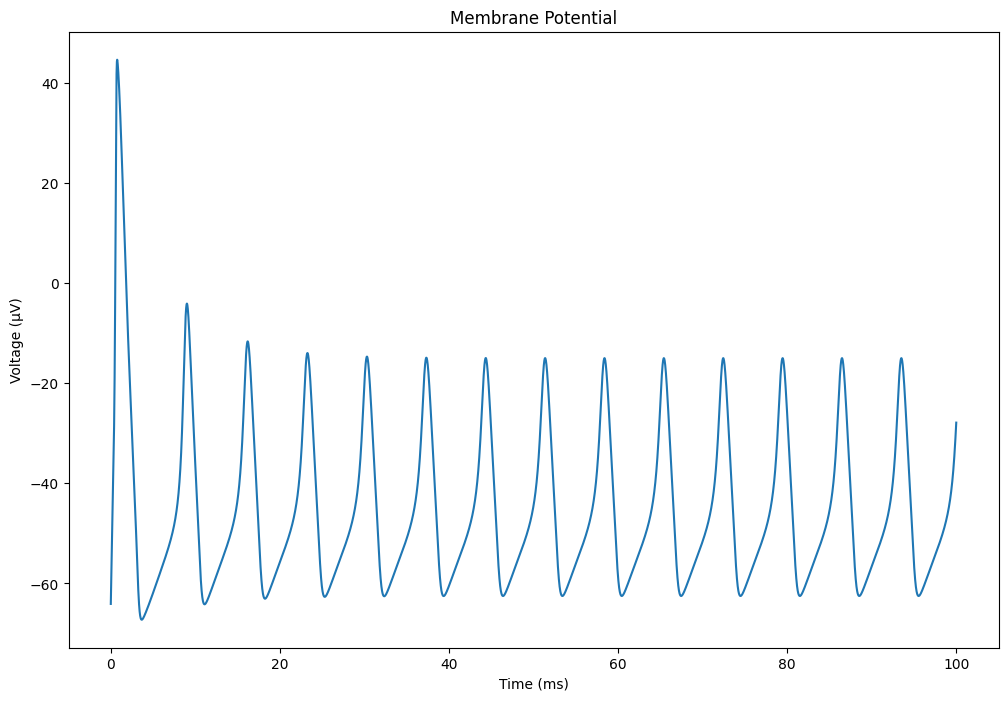

In [17]:
fig1 = plt.figure(figsize=(12, 8))
ax1 = plt.axes()

ax1.plot(t_range, v_hist)
ax1.set_title("Membrane Potential")
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Voltage (μV)");

Text(0, 0.5, 'Gate state')

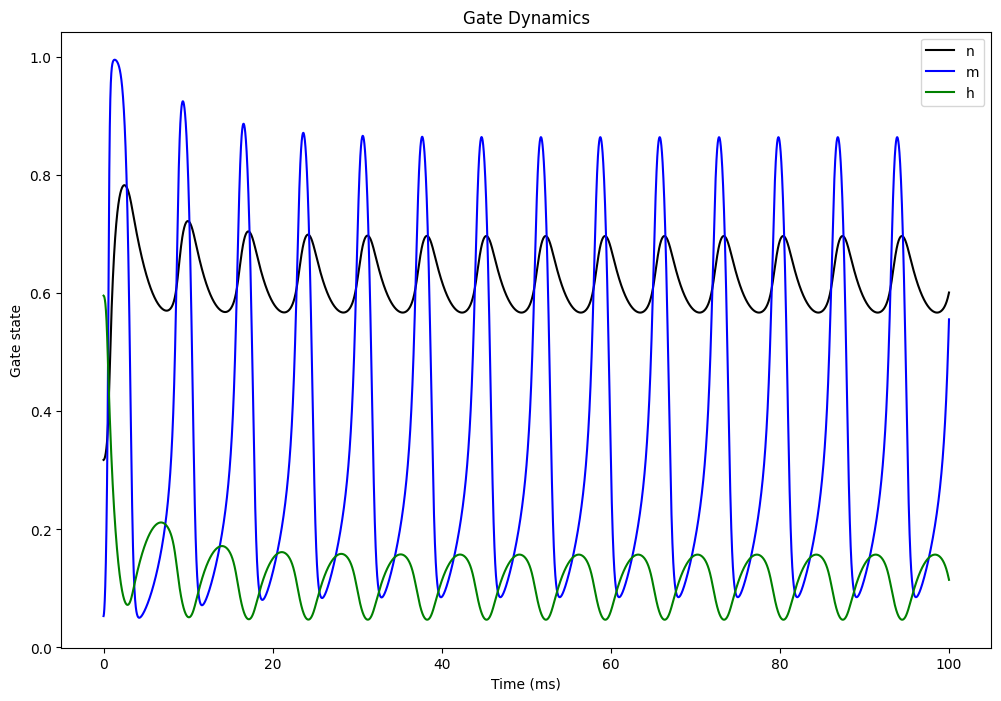

In [18]:
fig2 = plt.figure(figsize=(12, 8))
ax2 = plt.axes()

# TODO: Colour-blind accessibility
ax2.plot(t_range, n_hist, "k-", label="n")
ax2.plot(t_range, m_hist, "b-", label="m")
ax2.plot(t_range, h_hist, "g-", label="h")
ax2.legend()
ax2.set_title("Gate Dynamics")
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Gate state")

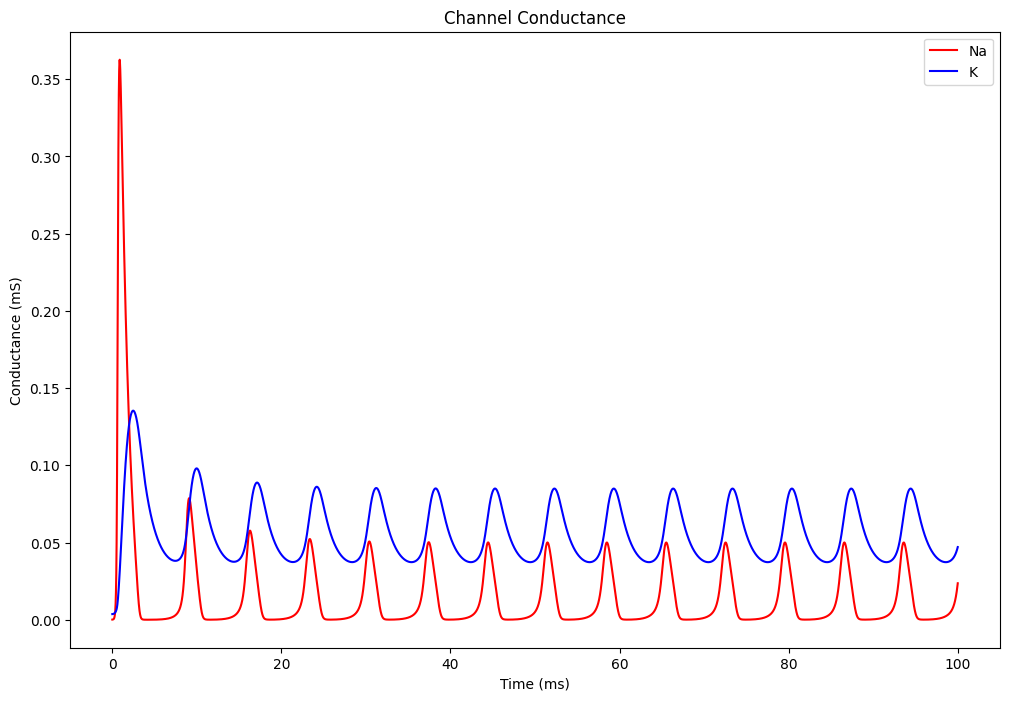

In [19]:
g_na_hist = na_g_max * np.multiply(np.power(m_hist, 3), h_hist)
g_k_hist = k_g_max * np.power(n_hist, 4)

fig3 = plt.figure(figsize=(12, 8))
ax3 = plt.axes()

ax3.plot(t_range, g_na_hist, 'r', label="Na")
ax3.plot(t_range, g_k_hist, 'b', label="K")
ax3.legend()
ax3.set_title("Channel Conductance")
ax3.set_xlabel("Time (ms)")
ax3.set_ylabel("Conductance (mS)");
plt.show()